### Imports

In [1]:
pip install mlflow dagshub optuna

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import optuna
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Experiment Tracking Server

In [3]:
import dagshub
dagshub.init(repo_owner='Yaxh8074', repo_name='sentiment-analysis-of-yt-comment', mlflow=True)

Accessing as Yaxh8074

Initialized MLflow to track repo "Yaxh8074/sentiment-analysis-of-yt-comment"

Repository Yaxh8074/sentiment-analysis-of-yt-comment initialized!

In [4]:
# Set or create an experiment
mlflow.set_experiment("Exp 5 - LightGBM HP Tuning")

2026/03/02 10:34:03 INFO mlflow.tracking.fluent: Experiment with name 'Exp 5 - LightGBM HP Tuning' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/96f88347140343d7a70e9ec507379c8a', creation_time=1772427846059, experiment_id='4', last_update_time=1772427846059, lifecycle_stage='active', name='Exp 5 - LightGBM HP Tuning', tags={}, workspace='default'>

### Helper Functions

In [13]:
# Define a function to vectorize the data using TF-IDF
def vectorize_data(X_train, X_val, X_test, max_features, ngram_range):
    from scipy.sparse import hstack, csr_matrix
    
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    X_train_vec = vectorizer.fit_transform(X_train['comment'].fillna('').astype(str))
    X_val_vec = vectorizer.transform(X_val['comment'].fillna('').astype(str))
    X_test_vec = vectorizer.transform(X_test['comment'].fillna('').astype(str))

    # Combine additional features (convert to sparse matrices to save memory)
    X_train_features = csr_matrix(X_train[['word_count', 'char_count', 'avg_word_length']].values)
    X_val_features = csr_matrix(X_val[['word_count', 'char_count', 'avg_word_length']].values)
    X_test_features = csr_matrix(X_test[['word_count', 'char_count', 'avg_word_length']].values)
    
    X_train_combined = hstack([X_train_vec, X_train_features])
    X_val_combined = hstack([X_val_vec, X_val_features])
    X_test_combined = hstack([X_test_vec, X_test_features])

    return X_train_combined, X_val_combined, X_test_combined


# Define the function that evaluates the model on validation data
def evaluate_model(model, X_val, y_val):
    y_val_pred = model.predict(X_val)  # Predict on validation set
    f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)  # Calculate F1 (macro)
    accuracy = accuracy_score(y_val, y_val_pred)  # Calculate accuracy
    return f1, accuracy, y_val_pred

### Read and Vectorize Data

In [14]:
df = pd.read_csv('../preprocessed_data.csv').dropna()

# Remap the class labels from [-1, 0, 1] to [0, 1, 2]
df['category'] = df['category'].map({-1: 0, 0: 1, 1: 2})

df.shape

(36662, 5)

In [15]:
max_features = 9410
ngram_range = (1, 2)

# Split data into training, validation and testing sets
X = df[['comment', 'word_count', 'char_count', 'avg_word_length']]
y = df['category']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.4, random_state=42, stratify=y_temp)

In [16]:
# Vectorize the data
X_train_combined, X_val_combined, X_test_combined = vectorize_data(X_train, X_val, X_test, max_features, ngram_range)

### HP Tuning using Optuna

In [17]:
# Define the Optuna objective function for LightGBM
def objective_lgbm(trial):

    n_estimators = trial.suggest_int("n_estimators", 150, 1000, step=10)
    max_depth = trial.suggest_int("max_depth", 3, 25)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
    num_leaves = trial.suggest_int("num_leaves", 20, 150)
    min_child_samples = trial.suggest_int("min_child_samples", 5, 100)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)

    # Initialize LightGBM model with GPU support
    model = lgb.LGBMClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        objective='multiclass',
        num_class=3,
        class_weight='balanced',
        random_state=42
    )

    # Log each trial to MLflow
    trial_name = f"trial-{trial.number + 1}"
    with mlflow.start_run(run_name=trial_name):
        # Fit the model on the training data
        model.fit(X_train_combined, y_train)

        # Evaluate model on the validation set
        f1, accuracy, y_val_pred = evaluate_model(model, X_val_combined, y_val)

        # Log hyperparameters and metrics to MLflow
        mlflow.log_params({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "learning_rate": learning_rate,
            "num_leaves": num_leaves,
            "min_child_samples": min_child_samples,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "reg_alpha": reg_alpha,
            "reg_lambda": reg_lambda,
            "objective": 'multiclass',
            "num_class": 3,
            "class_weight": 'balanced',
            "random_state": 42
        })

        mlflow.log_metric("accuracy", accuracy)

        # Logging the classification report
        classification_rep = classification_report(y_val, y_val_pred, output_dict=True)
        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
                for metric, value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric}", value)

        # Confusion matrix plot
        conf_matrix = confusion_matrix(y_val, y_val_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")

        # Save and log the confusion matrix plot
        plt.savefig("confusion_matrix.png")
        mlflow.log_artifact("confusion_matrix.png")
        plt.close()

    return accuracy, f1

[I 2026-03-02 10:40:30,020] A new study created in memory with name: LightGBM_Optimization


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 78685
[LightGBM] [Info] Number of data points in the train set: 27496, number of used features: 968
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

[I 2026-03-02 10:41:23,420] Trial 0 finished with values: [0.718130569194399, 0.6994817293923674] and parameters: {'n_estimators': 700, 'max_depth': 17, 'learning_rate': 0.003781812708396621, 'num_leaves': 75, 'min_child_samples': 89, 'subsample': 0.7125459106238887, 'colsample_bytree': 0.6564718849992264, 'reg_alpha': 0.03966357719552799, 'reg_lambda': 0.0010976057927243258}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091513 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 105939
[LightGBM] [Info] Number of data points in the train set: 27496, number of used features: 2377
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

[I 2026-03-02 10:43:29,971] Trial 1 finished with values: [0.7324968176032006, 0.7159839001550329] and parameters: {'n_estimators': 1000, 'max_depth': 17, 'learning_rate': 0.00229188470956544, 'num_leaves': 117, 'min_child_samples': 36, 'subsample': 0.8570821315033949, 'colsample_bytree': 0.6401866692839122, 'reg_alpha': 0.07760886959705886, 'reg_lambda': 0.8222343305378329}.


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 85671
[LightGBM] [Info] Number of data points in the train set: 27496, number of used features: 1223
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

[I 2026-03-02 10:56:52,774] Trial 11 finished with values: [0.7705037279505365, 0.7541989640989114] and parameters: {'n_estimators': 890, 'max_depth': 16, 'learning_rate': 0.008815128318156507, 'num_leaves': 80, 'min_child_samples': 70, 'subsample': 0.9357878497860661, 'colsample_bytree': 0.522205096386046, 'reg_alpha': 5.561600041000573, 'reg_lambda': 0.0003221257887017938}.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.135887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 122117
[LightGBM] [Info] Number of data points in the train set: 27496, number of used features: 3971
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

[W 2026-03-02 10:59:26,837] Trial 12 failed with parameters: {'n_estimators': 920, 'max_depth': 19, 'learning_rate': 0.01900224829755381, 'num_leaves': 75, 'min_child_samples': 21, 'subsample': 0.6475690769919775, 'colsample_bytree': 0.5982938703011318, 'reg_alpha': 1.9424583062600397e-05, 'reg_lambda': 8.819990595859532e-05} because of the following error: MemoryError('In RendererAgg: Out of memory').
Traceback (most recent call last):
  File "C:\Users\krish\AppData\Roaming\Python\Python312\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\krish\AppData\Local\Temp\ipykernel_4012\78079718.py", line 69, in objective_lgbm
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
  File "c:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py", line 459, in heatmap
    plotter.plot(ax, cbar_ax, kwargs)
  File "c:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py", line 3

MemoryError: In RendererAgg: Out of memory

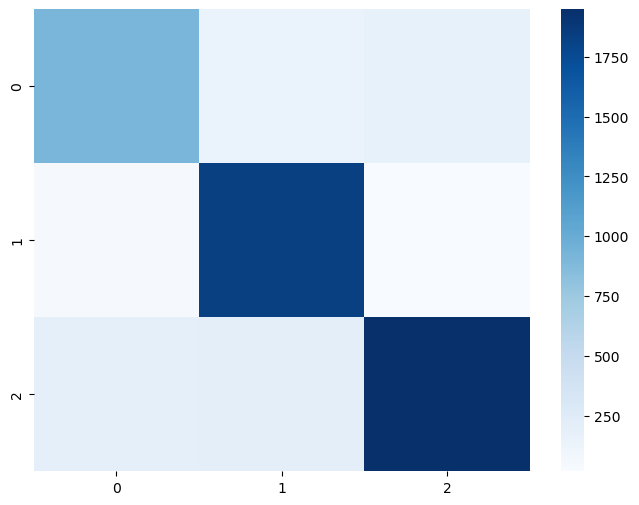

In [18]:
# Run Optuna optimization
study_lgbm = optuna.create_study(directions=["maximize", "maximize"], study_name="LightGBM_Optimization")  # Multi-objective optimization for both F1 and accuracy
study_lgbm.optimize(objective_lgbm, n_trials=150)

In [ ]:
best_trial = sorted(study_lgbm.best_trials, key=lambda t: t.values[0], reverse=True)[0]
best_trial

FrozenTrial(number=125, state=TrialState.COMPLETE, values=[0.8616112020367339, 0.8493941136484504], datetime_start=datetime.datetime(2024, 10, 27, 13, 21, 54, 147258), datetime_complete=datetime.datetime(2024, 10, 27, 13, 25, 13, 486927), params={'n_estimators': 980, 'max_depth': 11, 'learning_rate': 0.040414882180645394, 'num_leaves': 79, 'min_child_samples': 23, 'subsample': 0.9653126342291365, 'colsample_bytree': 0.7616387832635141, 'reg_alpha': 1.8391205366209559e-06, 'reg_lambda': 0.0005919096233992369}, user_attrs={}, system_attrs={'nsga2:generation': 2}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=150, step=10), 'max_depth': IntDistribution(high=25, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.0001, step=None), 'num_leaves': IntDistribution(high=150, log=False, low=20, step=1), 'min_child_samples': IntDistribution(high=100, log=False, low=5, step=1), 'subsample': FloatDistribution(hig

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.571198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 119249
[LightGBM] [Info] Number of data points in the train set: 27496, number of used features: 3630
[LightGBM] [Info] Start training from score -1.491752
[LightGBM] [Info] Start training from score -1.064540
[LightGBM] [Info] Start training from score -0.843655
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

Text(0.5, 1.0, 'Confusion Matrix - LightGBM')

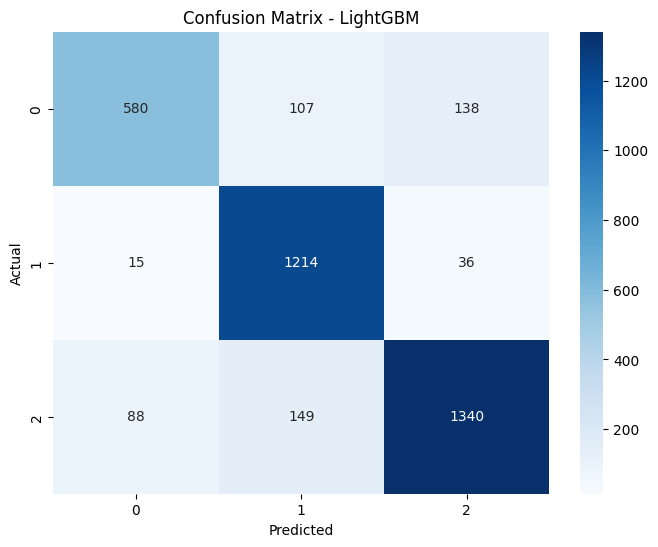

In [ ]:
# Extract parameters from the best trial
best_params = best_trial.params

# Initialize the model using the best trial parameters with unpacking (**)
model = lgb.LGBMClassifier(
                          objective='multiclass',   # Multi-class classification objective
                          num_class=3,              # Number of classes
                          random_state=42, **best_trial.params)

# Train the model on the resampled training data
model.fit(X_train_combined, y_train)

# Predictions on the test set
y_test_pred = model.predict(X_test_combined)

# Log classification metrics
classification_rep = classification_report(y_test, y_test_pred, output_dict=True)
accuracy = accuracy_score(y_test, y_test_pred)

# Generate and log confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - LightGBM")

In [ ]:
import re
import numpy as np

# Assuming you have pre-trained tfidf_vectorizer and lgbm_model loaded
# tfidf_vectorizer: Your trained TF-IDF vectorizer
# lgbm_model: Your trained LightGBM model

# Function to clean and preprocess a YouTube comment (same as used during training)
def preprocess_comment(comment):
    # Lowercasing
    comment = comment.lower()

    # Remove special characters, URLs, punctuation, and extra spaces
    comment = re.sub(r"http\S+|www\S+|https\S+", '', comment, flags=re.MULTILINE)  # Remove URLs
    comment = re.sub(r'\W', ' ', comment)  # Remove special characters
    comment = re.sub(r'\s+', ' ', comment).strip()  # Remove extra spaces and newlines

    return comment

# Prediction function
def predict_sentiment(comment, tfidf_vectorizer, lgbm_model):
    # Step 1: Preprocess the YouTube comment
    cleaned_comment = preprocess_comment(comment)

    # Step 2: Transform the comment using the trained TF-IDF vectorizer
    comment_tfidf = tfidf_vectorizer.transform([cleaned_comment])

    # Step 3: Use the trained LightGBM model to predict the sentiment
    prediction = model.predict(comment_tfidf)
    prediction_proba = model.predict_proba(comment_tfidf)

    # Step 4: Get the predicted sentiment (label) and probability
    sentiment_class = np.argmax(prediction_proba)
    sentiment_proba = np.max(prediction_proba)

    # Step 5: Return the sentiment label and confidence
    return {
        'sentiment_class': int(prediction[0]),  # -1, 0, or 1 depending on your labels
        'confidence': sentiment_proba
    }

# Example usage:
comment1 = "I absolutely hate this video!"
comment2 = "The explanations were confusing and the video quality was poor."
comment3 = "I didn’t learn anything useful. Really disappointed."
comment4 = "Wow, the explanation was so clear and helpful. Definitely subscribing!"
comment5 = "This is the worst video I’ve seen on this topic, very misleading"
comment6 = "Not much to say about this, just a standard video."
comment7 = "The video is okay, but I expected more depth in the content."
comment8 = "Superb content! Mazaa aa gaya dekh ke. Best video on this topic!"
comment9 = "Poor video quality aur explanation bhi weak tha."
comment10 = "Yeh video theek tha, but I was expecting more depth."
result = predict_sentiment(comment10, tfidf_cleaned, best_model)
print(f"Predicted Sentiment: {result['sentiment_class']}, Confidence: {result['confidence']}")

Predicted Sentiment: 0, Confidence: 0.7993257111935146
